# **Preparación y análisis de datos**

Este cuaderno contiene la preparación y análisis exploratorio de los datos


In [1]:
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

try:
    from pipeline.preprocessing import preprocess_df, normalize_breed_name
    from pipeline.vectorizers import vectorize_text_tfidf, vectorize_numerical
    

except ImportError as e:
    print(f"Error de importación: {e}")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/joseenriquerojas/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/joseenriquerojas/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/joseenriquerojas/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/joseenriquerojas/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## **1. Importación de librerías y configuración de gráficas**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configuramos las librerías de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = [10, 6]

## **2. Carga de Datos**

In [3]:
# Cargamos el corpus de razas de perros
df = pd.read_csv('data/akc-data-latest.csv')

# Mostramos información básica del dataset
print(f"Dimensiones del dataset: {df.shape}")
print(f"Número de razas: {len(df)}")
print(f"Columnas disponibles: {len(df.columns)}")

# Mostramso primeras filas
df.head()

Dimensiones del dataset: (277, 21)
Número de razas: 277
Columnas disponibles: 21


,breed,description,temperament,popularity,min_height,max_height,min_weight,max_weight,min_expectancy,max_expectancy,...,grooming_frequency_value,grooming_frequency_category,shedding_value,shedding_category,energy_level_value,energy_level_category,trainability_value,trainability_category,demeanor_value,demeanor_category
0,Affenpinscher,The Affen’s apish look has been described many...,"Confident, Famously Funny, Fearless",148,22.86,29.21,3.175147,4.535924,12.0,15.0,...,0.6,2-3 Times a Week Brushing,0.6,Seasonal,0.6,Regular Exercise,0.8,Easy Training,1.0,Outgoing
1,Afghan Hound,"The Afghan Hound is an ancient breed, his whol...","Dignified, Profoundly Loyal, Aristocratic",113,63.50,68.58,22.679619,27.215542,12.0,15.0,...,0.8,Daily Brushing,0.2,Infrequent,0.8,Energetic,0.2,May be Stubborn,0.2,Aloof/Wary
2,Airedale Terrier,The Airedale Terrier is the largest of all ter...,"Friendly, Clever, Courageous",60,58.42,58.42,22.679619,31.751466,11.0,14.0,...,0.6,2-3 Times a Week Brushing,0.4,Occasional,0.6,Regular Exercise,1.0,Eager to Please,0.8,Friendly
3,Akita,"Akitas are burly, heavy-boned spitz-type dogs ...","Courageous, Dignified, Profoundly Loyal",47,60.96,71.12,31.751466,58.967008,10.0,13.0,...,0.8,Daily Brushing,0.6,Seasonal,0.8,Energetic,1.0,Eager to Please,0.6,Alert/Responsive
4,Alaskan Malamute,The Alaskan Malamute stands 23 to 25 inches at...,"Affectionate, Loyal, Playful",58,58.42,63.50,34.019428,38.555351,10.0,14.0,...,0.6,2-3 Times a Week Brushing,0.6,Seasonal,0.8,Energetic,0.4,Independent,0.8,Friendly


## **3. Exploración de datos**

In [4]:
# Mostramos información del corpus, columnas, tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   breed                        277 non-null    object 
 1   description                  277 non-null    object 
 2   temperament                  276 non-null    object 
 3   popularity                   198 non-null    object 
 4   min_height                   277 non-null    float64
 5   max_height                   277 non-null    float64
 6   min_weight                   275 non-null    float64
 7   max_weight                   275 non-null    float64
 8   min_expectancy               274 non-null    float64
 9   max_expectancy               274 non-null    float64
 10  group                        277 non-null    object 
 11  grooming_frequency_value     270 non-null    float64
 12  grooming_frequency_category  270 non-null    object 
 13  shedding_value      

In [5]:
# Mostramos estadísticas descriptivas, incluyendo conteo, media, desviación estándar, mínimo, percentiles y máximo
df.describe().T

,count,mean,std,min,25%,50%,75%,max
min_height,277.0,44.225801,14.238298,12.70,33.020000,45.085000,55.880000,76.200000
max_height,277.0,52.720588,15.885454,17.78,38.100000,53.340000,66.040000,88.900000
min_weight,275.0,17.888858,12.290600,0.00,8.164663,15.875733,22.679619,68.038855
max_weight,275.0,27.291416,19.061416,0.00,12.927383,24.947580,34.019428,108.862169
min_expectancy,274.0,11.306569,1.817949,0.00,10.000000,12.000000,12.000000,16.000000
max_expectancy,274.0,13.832117,2.016668,0.00,13.000000,14.000000,15.000000,19.000000
grooming_frequency_value,270.0,0.425926,0.198306,0.20,0.200000,0.400000,0.600000,1.000000
shedding_value,257.0,0.529183,0.189068,0.20,0.400000,0.600000,0.600000,1.000000
energy_level_value,271.0,0.712915,0.168927,0.20,0.600000,0.600000,0.800000,1.000000
trainability_value,253.0,0.624506,0.247271,0.20,0.400000,0.600000,0.800000,1.000000


In [6]:
# Mostramos valores faltantes en el dataset
missing_values = df.isnull().sum()
# Calculamos el porcentaje de valores faltantes
missing_percent = (missing_values / len(df)) * 100
# Creamos un DataFrame con los valores faltantes y su porcentaje
# y lo ordenamos de mayor a menor y filtramos para mostrar solo las columnas con valores faltantes
missing_df = pd.DataFrame({'Valores faltantes': missing_values, 'Porcentaje': missing_percent})
missing_df = missing_df[missing_df['Valores faltantes'] > 0].sort_values('Valores faltantes', ascending=False)

print("Columnas con valores faltantes:")
if len(missing_df) > 0:
    display(missing_df)
else:
    print("No hay valores faltantes en el dataset.")

Columnas con valores faltantes:


,Valores faltantes,Porcentaje
popularity,79,28.519856
demeanor_value,25,9.025271
demeanor_category,25,9.025271
trainability_value,24,8.664260
trainability_category,24,8.664260
shedding_value,20,7.220217
shedding_category,20,7.220217
grooming_frequency_value,7,2.527076
grooming_frequency_category,7,2.527076
energy_level_value,6,2.166065


## **4. Análisis de variables categóricas**

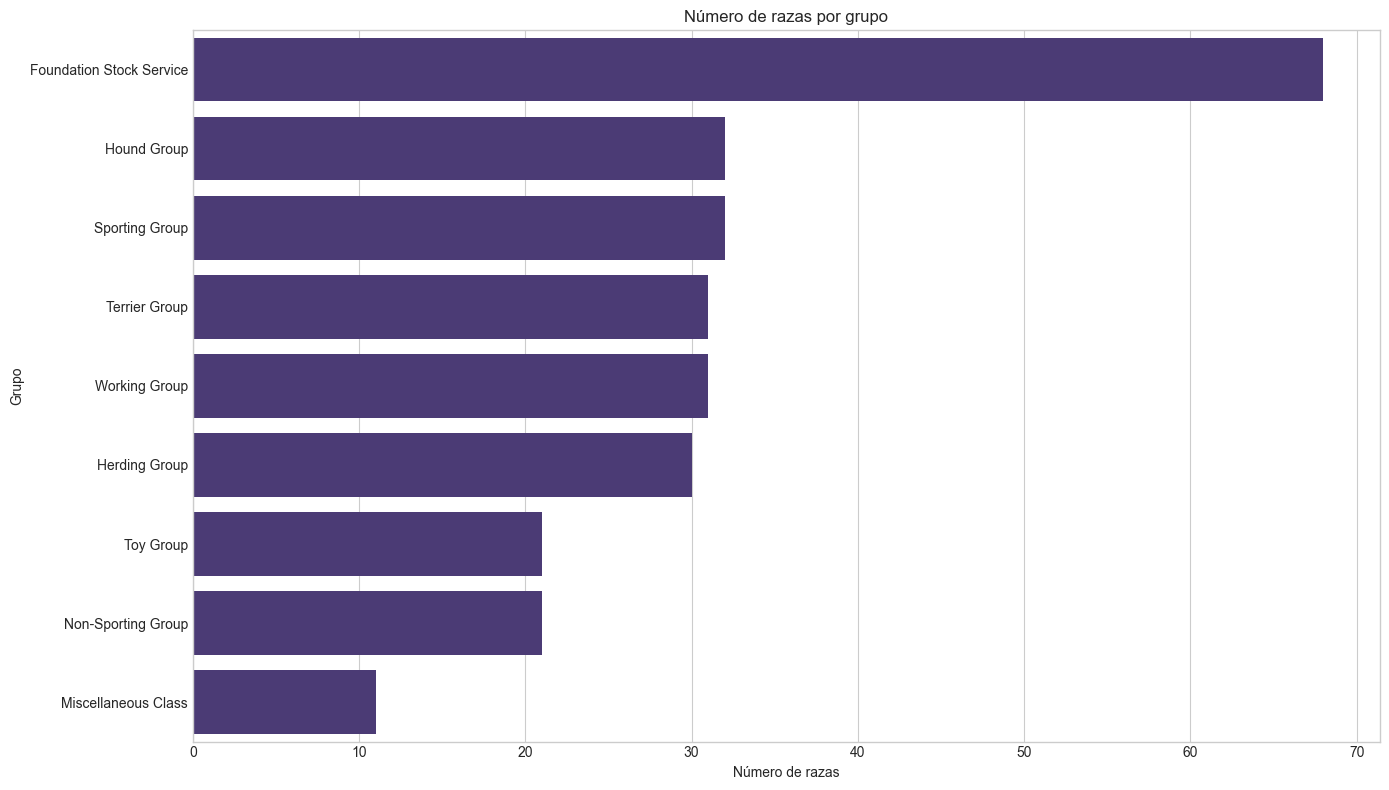

In [7]:
# Mostramos la distribución de grupos de razas
plt.figure(figsize=(14, 8))
group_counts = df['group'].value_counts()
sns.barplot(x=group_counts.values, y=group_counts.index)
plt.title('Número de razas por grupo')
plt.xlabel('Número de razas')
plt.ylabel('Grupo')
plt.tight_layout()
plt.show()

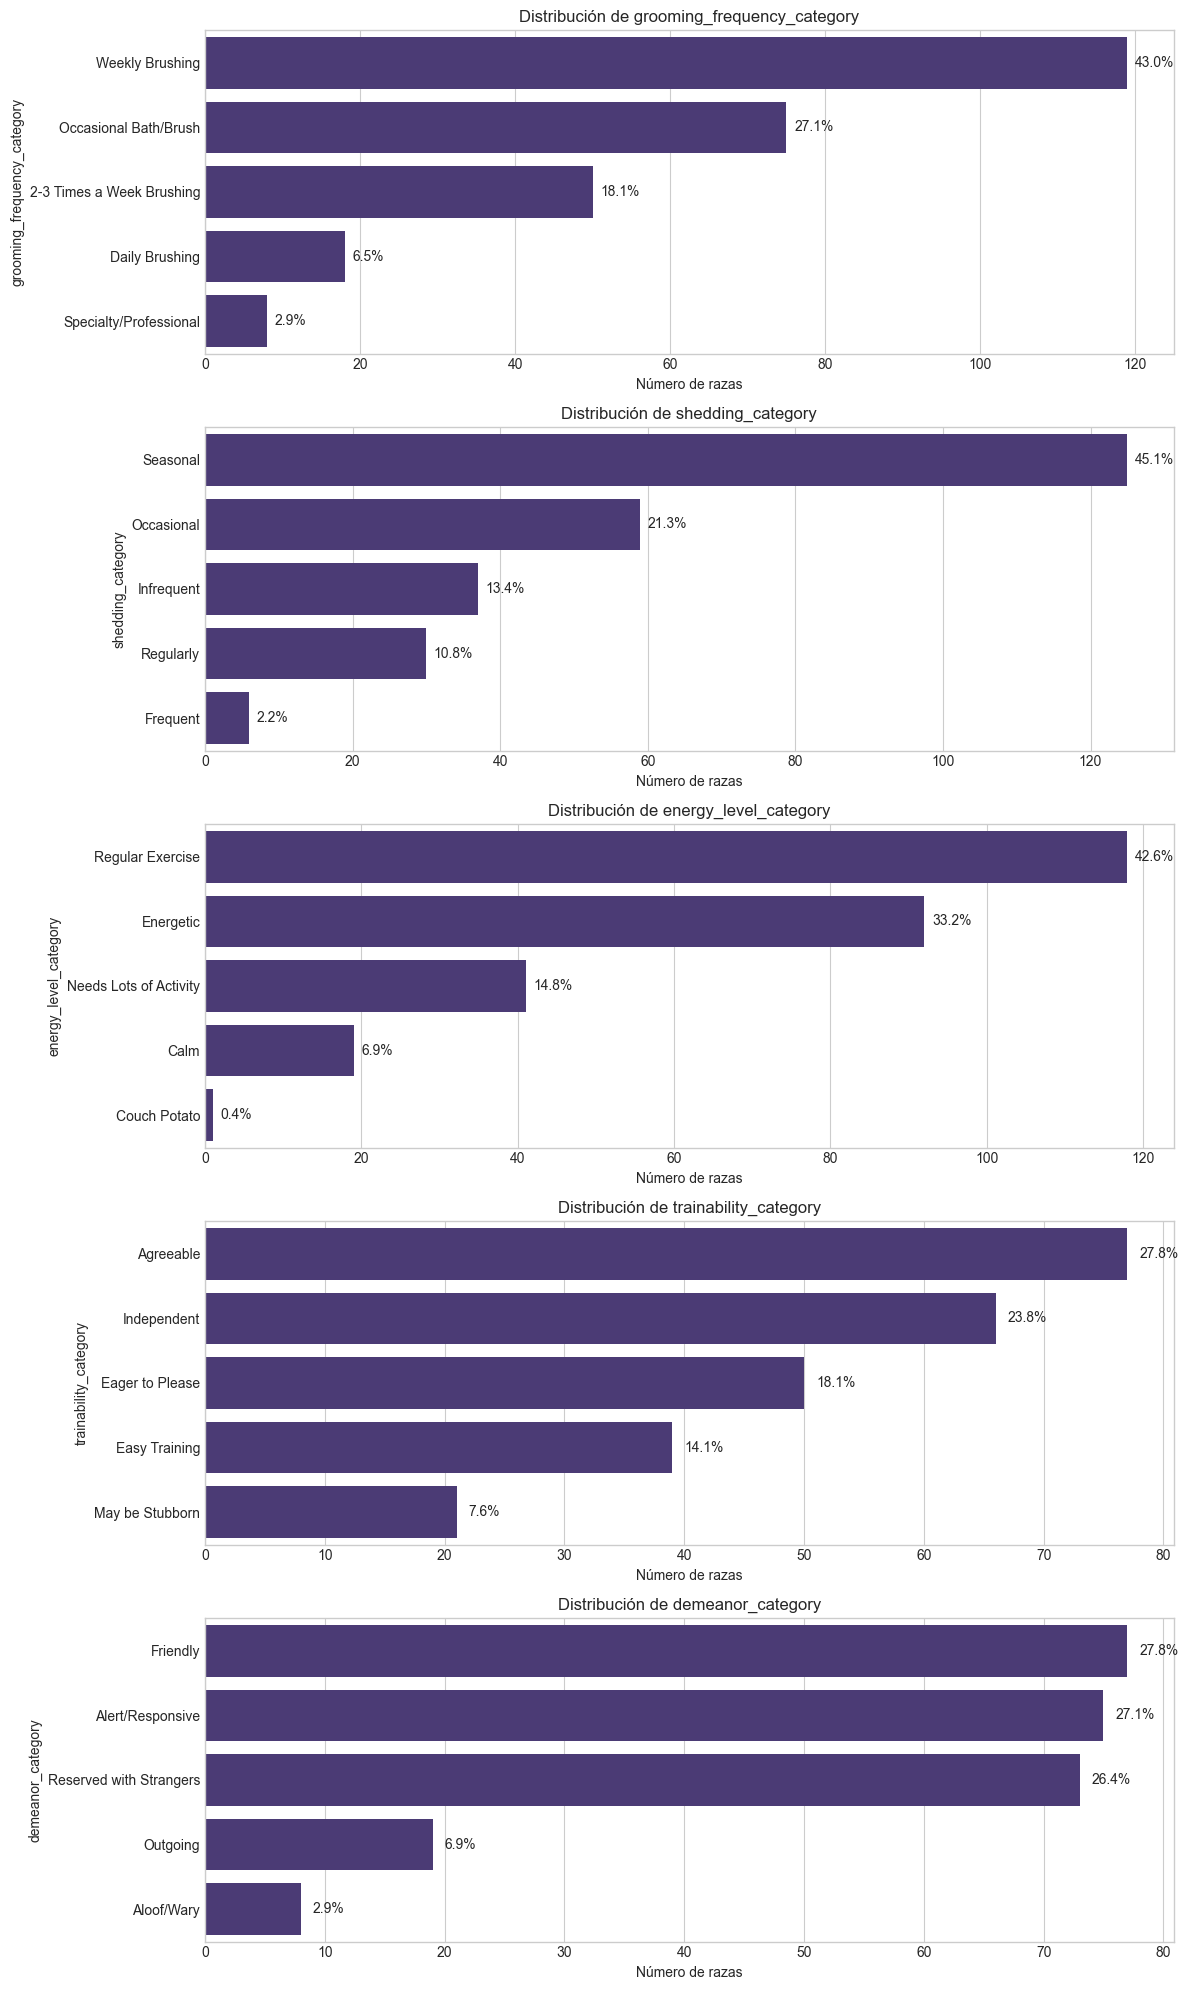

In [8]:
# Obtenemos la distribución por categoría
categorical_cols = [
    "grooming_frequency_category",
    "shedding_category",
    "energy_level_category",
    "trainability_category",
    "demeanor_category"
]

fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 20))

for i, col in enumerate(categorical_cols):
    sns.countplot(y=df[col], ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('Número de razas')
    # Añadimos etiquetas de porcentaje
    total = len(df)
    for j, p in enumerate(axes[i].patches):
        width = p.get_width()
        axes[i].text(width + 1, p.get_y() + p.get_height()/2, 
                f'{width/total:.1%}', 
                ha='left', va='center')

plt.tight_layout()
plt.show()

## **5. Análisis de variables numéricas**

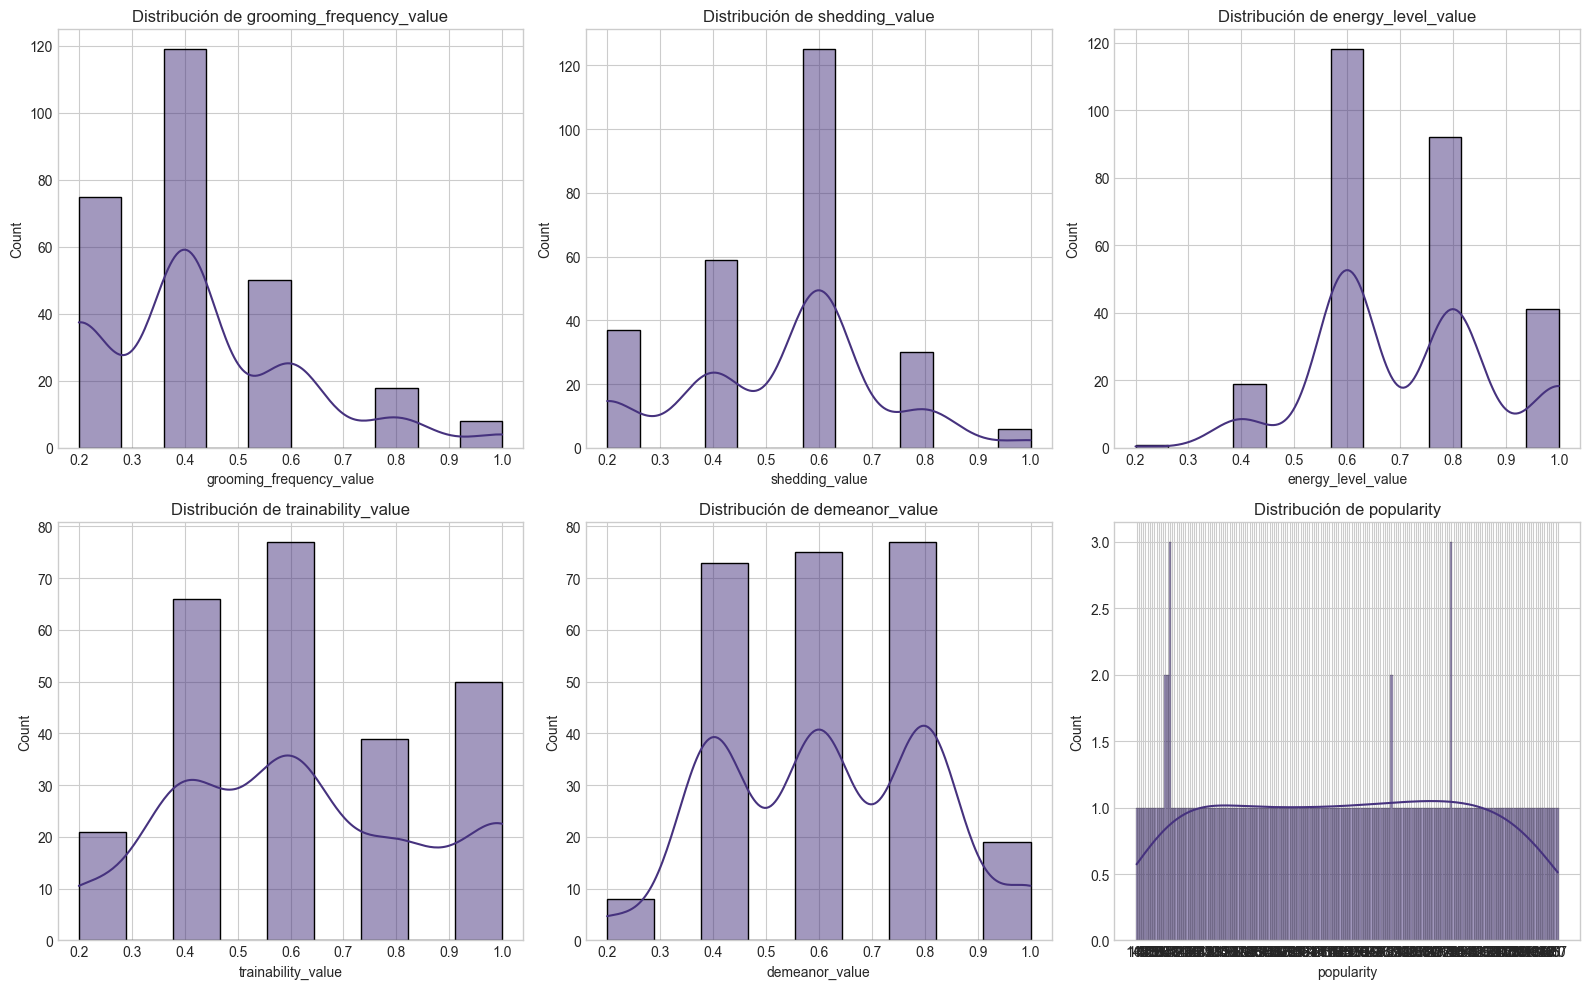

In [9]:
# Mostamos la distribución de variables ordinales
numerical_cols = [
    "grooming_frequency_value",
    "shedding_value",
    "energy_level_value",
    "trainability_value",
    "demeanor_value",
    "popularity"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    
plt.tight_layout()
plt.show()

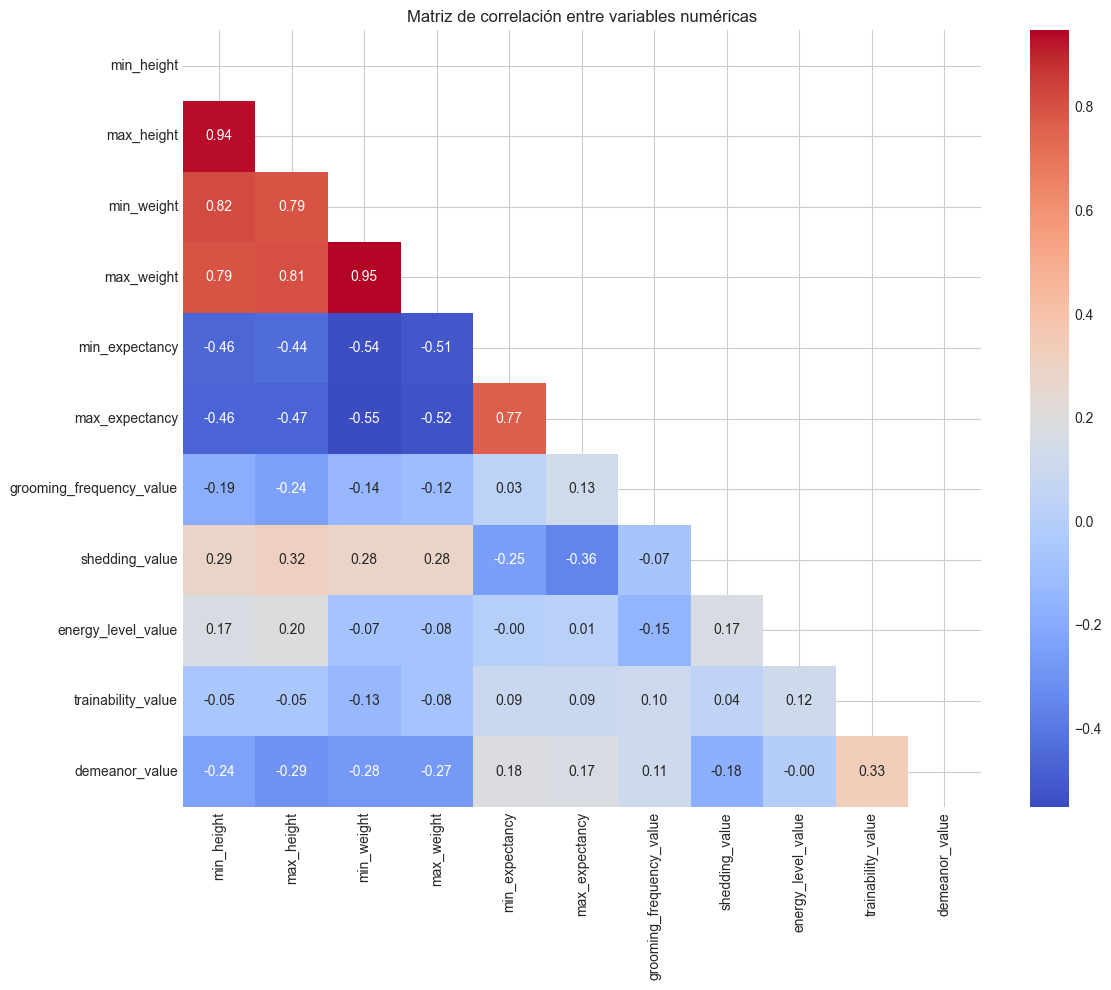

In [10]:
# Filtramos solo las columnas numéricas para la matriz de correlación
numerical_cols = df.select_dtypes(include=['number']).columns
# Creamos una matriz de correlación entre las variables numéricas
corr_matrix = df[numerical_cols].corr()

# Mostramos la matriz de correlación
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=mask)
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

## **6. Análisis de texto**

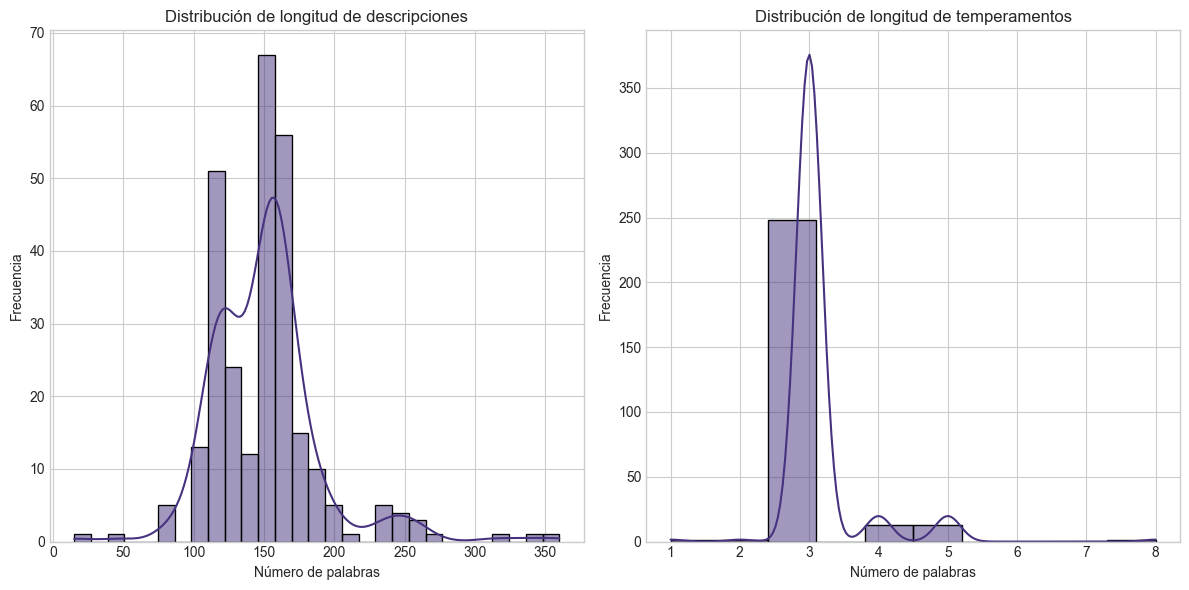

In [11]:
# Mostramos la distribución de la longitud de las descripciones y temperamentos
# para ello, calculamos la longitud de las descripciones y temperamentos
df['description_length'] = df['description'].apply(lambda x: len(str(x).split()))
df['temperament_length'] = df['temperament'].apply(lambda x: len(str(x).split()))

# Mostramos la longitud de las descripciones y temperamentos
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['description_length'], kde=True)
plt.title('Distribución de longitud de descripciones')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df['temperament_length'], kde=True)
plt.title('Distribución de longitud de temperamentos')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

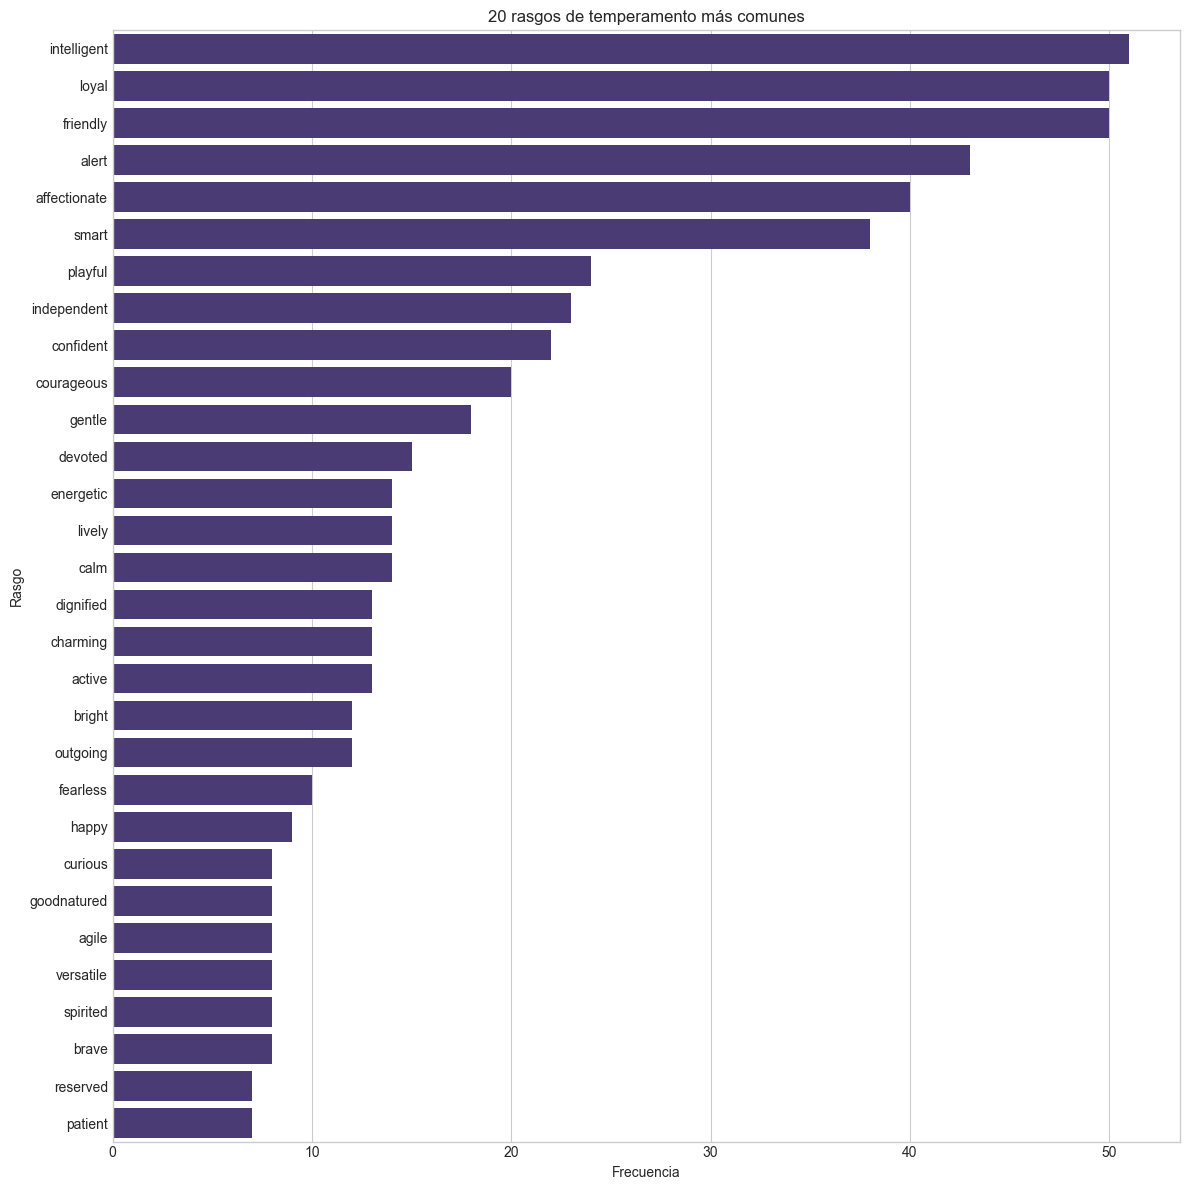

In [12]:
# Obtenemos la lista de palabras de temperamento 
from collections import Counter
import re

# Rellenamos valores nulos con una cadena vacía antes de procesar
df['temperament'] = df['temperament'].fillna('')

# Procesamos temperamentosco (vertimos a minúsculas y eliminamos comas)
all_temperament_words = ' '.join(df['temperament'].str.lower()).replace(',', '')
all_temperament_words = re.sub(r'[^\w\s]', '', all_temperament_words)
# Creamos una lista de palabras de temperamento
temperament_words = [word for word in all_temperament_words.split() if len(word) > 3]

# Contamos frecuencias
temp_counter = Counter(temperament_words)
common_traits = pd.DataFrame(temp_counter.most_common(30), columns=['Trait', 'Count'])

# Visualizamos los 20 rasgos de temperamento más comunes
plt.figure(figsize=(12, 12))
sns.barplot(x='Count', y='Trait', data=common_traits)
plt.title('20 rasgos de temperamento más comunes')
plt.xlabel('Frecuencia')
plt.ylabel('Rasgo')
plt.tight_layout()
plt.show()

## **7. Preprocesamiento de Datos**

In [ ]:
import nltk
nltk.download('punkt_tab')

In [13]:
from pipeline.preprocessing import preprocess_df

# Definimos columnas de texto a normalizar
text_columns = [
    "description",
    "temperament",
    "group",
    "breed",
    "grooming_frequency_category",
    "shedding_category",
    "energy_level_category",
    "trainability_category",
    "demeanor_category"
]

# Preprocesar dataframe con el pipeline de preprocesamiento que se encarga de normalizar
# y eliminar caracteres especiales, convertir a minúsculas, etc.
df_processed = preprocess_df(df, text_columns)

print("Ejemplo de datos preprocesados:")
# Mostramos las primeras filas del dataframe preprocesado
df_processed[['breed', 'group', 'temperament']].head()

/Users/joseenriquerojas/Developer/Maestria/DogRecSys/pipeline/preprocessing.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(median_value, inplace=True)
/Users/joseenriquerojas/Developer/Maestria/DogRecSys/pipeline/preprocessing.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

Ejemplo de datos preprocesados:


,breed,group,temperament
0,affenpinscher,toy_group,confident famously funny fearless
1,afghan_hound,hound_group,dignified profoundly loyal aristocratic
2,airedale_terrier,terrier_group,friendly clever courageous
3,akita,working_group,courageous dignified profoundly loyal
4,alaskan_malamute,working_group,affectionate loyal playful


In [14]:
# Mostramos ejemplos de las columnas preprocesadas para ver el efecto de la normalización

# Muestra de descripciones originales vs procesadas
print("\nEjemplo de preprocesamiento de texto:")
ejemplo_idx = 0  # Tomamos el primer ejemplo
print("\n--- Descripción original ---")
print(df.iloc[ejemplo_idx]['description'][:300] + "...")  # Mostramos los primeros 300 caracteres
print("\n--- Descripción procesada ---")
print(df_processed.iloc[ejemplo_idx]['description'][:300] + "...")

# Para propósitos de demostración, mostramos el funcionamiento del procesamiento de texto
from pipeline.text_processing import normalize_text

description_sample = df.iloc[ejemplo_idx]['description'][:100]
print("\n--- Proceso de normalización de texto ---")
print("Texto original:", description_sample)
print("Normalizado:", normalize_text(description_sample))
print("\nObserva cómo el texto ha sido normalizado: stopwords eliminadas, palabras lematizadas, etc.")

# Muestra de temperamentos originales vs procesados
print("\n\nEjemplo de preprocesamiento de temperamento:")
print("\n--- Temperamento original ---")
print(df.iloc[ejemplo_idx]['temperament'])
print("\n--- Temperamento procesado ---")
print(df_processed.iloc[ejemplo_idx]['temperament'])

# Mostramos columnas categóricas también
print("\n\nColumnas categóricas:")
cols_to_show = ['group', 'grooming_frequency_category', 'energy_level_category']
for col in cols_to_show:
    print(f"\n--- {col} original vs procesado ---")
    print(f"Original: {df.iloc[ejemplo_idx][col]}")
    print(f"Procesado: {df_processed.iloc[ejemplo_idx][col]}")


Ejemplo de preprocesamiento de texto:

--- Descripción original ---
The Affen’s apish look has been described many ways. They’ve been called “monkey dogs” and “ape terriers.” The French say diablotin moustachu (“mustached little devil”), and Star Wars fans argue whether they look more like Wookies or Ewoks.Standing less than a foot tall, these sturdy terrier-like do...

--- Descripción procesada ---
affen apish look described many way called monkey dog ape terrier french say diablotin moustachu mustached little devil star war fan argue whether look like wookies ewoks standing less foot tall sturdy terrier like dog approach life great confidence breed train professional dog handler tell u like h...

--- Proceso de normalización de texto ---
Texto original: The Affen’s apish look has been described many ways. They’ve been called “monkey dogs” and “ape terr
Normalizado: affen apish look described many way called monkey dog ape terr

Observa cómo el texto ha sido normalizado: stopwords el

## **8. Preparación de Datos para Modelos**

### Vectorización con TF-IDF y limpieza de texto

En nuestro sistema de recomendación basado en contenido, utilizamos TF-IDF para vectorizar el texto de las descripciones y características de cada raza de perro. Hemos implementado mejoras importantes en el preprocesamiento:

1. **Limpieza y normalización avanzada de texto**:
   - Eliminación de stopwords (palabras comunes sin valor semántico)
   - Lematización (reducción de palabras a su forma base)
   - Eliminación de caracteres especiales y números
   - Normalización de espacios y formato

Esta limpieza de texto nos permite trabajar con datos textuales de mayor calidad, enfocándonos en los términos que realmente aportan significado para la recomendación basada en contenido.

A continuación, aplicamos la vectorización TF-IDF:

In [15]:
from pipeline.vectorizers import vectorize_text_tfidf, vectorize_numerical

# Vectorizamos el texto utilizando TF-IDF con parámetros optimizados
# y guardamos el modelo para su uso posterior
X_text, tfidf_model = vectorize_text_tfidf(
    df_processed,
    column="text_combined", 
    max_features=500,
    min_df=0.01,            # Ignorar términos que aparecen en menos del 1% de documentos
    max_df=0.95,            # Ignorar términos que aparecen en más del 95% de documentos
    ngram_range=(1, 1)      # Solo unigramas (palabras individuales)
)
print(f"Dimensiones de vectores de texto: {X_text.shape}")

# Extraemos las 20 características más importantes (términos) del modelo TF-IDF
feature_names = tfidf_model.get_feature_names_out()
print(f"\nAlgunos términos importantes en el modelo TF-IDF:")
print(", ".join(feature_names[:20]))

# Vectorizamos los datos numéricos
numerical_columns = [
    "grooming_frequency_value",
    "shedding_value",
    "energy_level_value",
    "trainability_value",
    "demeanor_value"
]

X_num, scaler = vectorize_numerical(df_processed, numerical_columns)
print(f"\nDimensiones de vectores numéricos: {X_num.shape}")

Dimensiones de vectores de texto: (277, 500)

Algunos términos importantes en el modelo TF-IDF:
3_times_a_week_brushing, ability, active, activity, adaptable, affectionate, age, aggressive, agile, agility, agreeable, akc, alert, almond, aloof, america, american, americaname, amiable, amusing

Dimensiones de vectores numéricos: (277, 5)


In [16]:
# Evaluamos la calidad de la vectorización TF-IDF
from pipeline.preprocessing import normalize_breed_name

# Visualizamos las principales palabras para algunas razas específicas
import numpy as np

def get_top_tfidf_terms(tfidf_model, X_text, df, breed_name, top_n=10):
    """
    Obtiene los términos TF-IDF más importantes para una raza específica.
    """
    # Obtenemos el índice de la raza
    breed_idx = df[df['breed'] == normalize_breed_name(breed_name)].index[0]
    
    # Obtenemos los pesos TF-IDF para esta raza
    tfidf_weights = X_text[breed_idx].toarray()[0]
    
    # Obtenemos los nombres de las características
    feature_names = tfidf_model.get_feature_names_out()
    
    # Ordenamos los términos por su peso TF-IDF
    sorted_indices = np.argsort(tfidf_weights)[::-1]
    
    # Devolvemos los top_n términos más importantes
    top_terms = [(feature_names[i], tfidf_weights[i]) for i in sorted_indices[:top_n]]
    
    return top_terms

# Lista de razas para analizar
razas_ejemplo = ['Labrador Retriever', 'German Shepherd', 'Chihuahua', 'Poodle', 'Bulldog']

# Mostramos los términos más importantes para cada raza
for raza in razas_ejemplo:
    try:
        top_terms = get_top_tfidf_terms(tfidf_model, X_text, df_processed, raza)
        print(f"\nTérminos más importantes para {raza}:")
        for term, weight in top_terms:
            print(f"  - {term}: {weight:.4f}")
    except:
        print(f"No se pudo encontrar la raza: {raza}")


Términos más importantes para Labrador Retriever:
  - retriever: 0.3003
  - outgoing: 0.2926
  - faced: 0.1847
  - enthusiastic: 0.1847
  - swimming: 0.1809
  - famously: 0.1774
  - bond: 0.1711
  - looking: 0.1711
  - popular: 0.1632
  - spirited: 0.1608
No se pudo encontrar la raza: German Shepherd

Términos más importantes para Chihuahua:
  - graceful: 0.2295
  - time: 0.2001
  - going: 0.1701
  - oldest: 0.1666
  - like: 0.1640
  - cold: 0.1634
  - amusing: 0.1604
  - expressive: 0.1604
  - quality: 0.1604
  - attitude: 0.1604
No se pudo encontrar la raza: Poodle

Términos más importantes para Bulldog:
  - bulldog: 0.5556
  - courageous: 0.2153
  - short: 0.1742
  - skin: 0.1650
  - walk: 0.1529
  - country: 0.1504
  - docile: 0.1480
  - weather: 0.1480
  - courage: 0.1436
  - muscled: 0.1397


In [17]:
df_processed.to_csv('data/preprocessed_data.csv')
print("Conjunto de datos guardado en en 'data/preprocessed_data.csv'")

Conjunto de datos guardado en en 'data/preprocessed_data.csv'


## **9. Simulación de Matriz de Interacciones Usuario-Ítem**

In [ ]:
from pipeline.simulation import simulate_user_item_matrix

# Simulamos una matriz de usuario-ítem para recomendaciones de filtrado colaborativo
# utilizando la popularidad de las razas para la simulación (razas más populares recibirán más ratings)
ratings_matrix = simulate_user_item_matrix(
    df_processed,                   # DataFrame preprocesado
    n_users=150,                    # Número de usuarios a simular
    min_ratings=50,                 # Número mínimo de ratings por usuario
    max_ratings=120,                # Número máximo de ratings por usuario
    popularity_col="popularity"     # Columna de popularidad para simular ratings
)

# Mostramos la dimensión de la matriz de ratings
print(f"Dimensiones de la matriz de ratings: {ratings_matrix.shape}")

# Mostramos las primeras filas de la matriz de ratings
ratings_matrix.iloc[:5, :5]

In [ ]:
# Calculamos y mostramos estadísticas de la matriz de ratings

# Densidad de la matriz (proporción de ratings no nulos)
# La densidad se calcula como el número de ratings no nulos dividido por el total de posibles ratings
# (número de usuarios * número de ítems)
density = (ratings_matrix != 0).sum().sum() / (ratings_matrix.shape[0] * ratings_matrix.shape[1])

# Rating promedio (promedio de ratings no nulos)
# Se calcula como la suma de ratings no nulos dividido por el número de ratings no nulos
# Se utiliza .mean() para obtener el promedio de ratings no nulos
avg_rating = ratings_matrix[ratings_matrix > 0].mean().mean()

# Promedio de ratings por usuario (promedio de ratings no nulos por usuario)
# Se calcula como la suma de ratings no nulos por usuario dividido por el número de ratings no nulos por usuario
ratings_per_user = (ratings_matrix > 0).sum(axis=1)

# Promedio de ratings por ítem (promedio de ratings no nulos por ítem)
# Se calcula como la suma de ratings no nulos por ítem dividido por el número de ratings no nulos por ítem
ratings_per_item = (ratings_matrix > 0).sum(axis=0)

print(f"Densidad de la matriz: {density:.4f} ({density*100:.2f}%)")
print(f"Rating promedio: {avg_rating:.2f}")
print(f"Promedio de ratings por usuario: {ratings_per_user.mean():.2f}")
print(f"Promedio de ratings por raza: {ratings_per_item.mean():.2f}")
print(f"Rango de ratings por usuario: {ratings_per_user.min()} - {ratings_per_user.max()}")

In [ ]:
# Visualizamos las distribuciones
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma de ratings por usuario
sns.histplot(ratings_per_user, kde=True, ax=axes[0])
axes[0].set_title('Distribución de ratings por usuario')
axes[0].set_xlabel('Número de ratings')
axes[0].set_ylabel('Frecuencia')

# Histograma de ratings por raza
sns.histplot(ratings_per_item, kde=True, ax=axes[1])
axes[1].set_title('Distribución de ratings por raza')
axes[1].set_xlabel('Número de Ratings')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [ ]:
# Guardamos la matriz de ratings para uso en experimentación
ratings_matrix.to_csv('data/user_dog_ratings.csv')
print("Matriz de ratings guardada en 'data/user_dog_ratings.csv'")

## **10. Resumen**

### **Principales hallazgos del análisis exploratorio:**

1. **Dataset de razas:**
   - Contamos con información detallada de múltiples razas de perros.
   - Las variables numéricas ordinales están distribuidas en escala de 1-5.
   - Hay una buena diversidad de grupos de razas.

2. **Correlaciones**
   - Razas más altas también tienden a ser más pesadas.
   - Cuanto mayor es la raza, menor su esperanza de vida promedio.
   - Nivel de energía, frecuencia de aseo y grado de muda no están muy ligados entre sí ni con tamaño.
   - Los perros más grandes tienden a mudar más pelo. Sin embargo, la frecuencia de aseo tiene correlaciones muy débiles o incluso ligeramente negativas con el tamaño y grado de muda.
   - Los perros con mejor “comportamiento/temperamento” suelen ser también más entrenables.
   - La extensión de la descripción o del texto del temperamento no depende de las características cuantitativas de la raza.


3. **Datos textuales:**
   - Las descripciones y temperamentos proporcionan información rica para análisis basado en contenido.
   - Los rasgos de temperamento más comunes incluyen "intelligent", "loyal", "friendly" y "alert".

4. **Matriz de ratings simulada:**
   - Densidad del 31.34%.
   - Distribución de ratings que imita patrones de sistemas de recomendación cotidianos (cola larga).

